In [1]:
import pandas as pd
from scripts.aux_msa_functions import *
from scipy.spatial.distance import cdist
import os
import numpy as np
import torch
from Bio import Phylo
import seaborn as sns
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
import re
from scipy.stats import pearsonr
from math import floor,ceil
from scipy import stats
import subprocess



torch.set_grad_enabled(False)

In [2]:
deletekeys = dict.fromkeys(string.ascii_lowercase)
deletekeys["."] = None
deletekeys["*"] = None
translation = str.maketrans(deletekeys)

def read_sequence(filename: str) -> Tuple[str, str]:
    """ Reads the first (reference) sequences from a fasta or MSA file."""
    record = next(SeqIO.parse(filename, "fasta"))
    return record.description, str(record.seq)

def remove_insertions(sequence: str) -> str:
    """ Removes any insertions into the sequence. Needed to load aligned sequences in an MSA. """
    return sequence.translate(translation)

def read_msa(filename: str) -> List[Tuple[str, str]]:
    """ Reads the sequences from an MSA file, automatically removes insertions."""
    return [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse(filename, "fasta")]

def greedy_select(msa: List[Tuple[str, str]], num_seqs: int, mode: str = "max") -> List[Tuple[str, str]]:
    assert mode in ("max", "min")
    if len(msa) <= num_seqs:
        return msa
    
    array = np.array([list(seq) for _, seq in msa], dtype=np.bytes_).view(np.uint8)

    optfunc = np.argmax if mode == "max" else np.argmin
    all_indices = np.arange(len(msa))
    indices = [0]
    pairwise_distances = np.zeros((0, len(msa)))
    for _ in range(num_seqs - 1):
        dist = cdist(array[indices[-1:]], array, "hamming")
        pairwise_distances = np.concatenate([pairwise_distances, dist])
        shifted_distance = np.delete(pairwise_distances, indices, axis=1).mean(0)
        shifted_index = optfunc(shifted_distance)
        index = np.delete(all_indices, indices)[shifted_index]
        indices.append(index)
    indices = sorted(indices)
    return [msa[idx] for idx in indices]

def Seq_tuples_to_fasta(sequences, file_path, export_type = "fasta"):
    MSA_SeqRecords = [SeqRecord(Seq(record[1]), id = record[0], name= record[0], description= record[0]) for record in sequences]
    with open(f"{file_path}", "w") as output_handle:
        SeqIO.write(MSA_SeqRecords, output_handle, export_type)

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from Bio import SeqIO
from scripts.aux_msa_functions import *


def custom_mi(values_1, values_2, domain_1 = list("-ACDEFGHIKLMNPQRSTVWY"), domain_2 = list("-ACDEFGHIKLMNPQRSTVWY"), pseudocount = 0):

    assert len(values_1) == len(values_2), 'arrays must be of the same length'
    
    values_1_counts = {}
    values_2_counts = {}
    joint_counts = {}
    mi = 0

    for elem_1 in domain_1:
        for elem_2 in domain_2:
            joint_counts[(elem_1, elem_2)] = pseudocount
    
    for elem_1 in domain_1:
        values_1_counts[elem_1] = pseudocount * len(domain_2)
    
    for elem_2 in domain_2:
        values_2_counts[elem_2] = pseudocount * len(domain_1)

    for i in range(len(values_1)):

        elem_1 = values_1[i]
        elem_2 = values_2[i]

        values_1_counts[elem_1] += 1
        values_2_counts[elem_2] += 1

        joint_counts[(elem_1, elem_2)] += 1

    total_counts = pseudocount * len(domain_1) * len(domain_2) + len(values_1)
    
    for elem_1 in domain_1:
        for elem_2 in domain_2:

            probs_elem_1 = values_1_counts[elem_1] / total_counts
            probs_elem_2 = values_2_counts[elem_2] / total_counts
            joint_probs = joint_counts[(elem_1, elem_2)] / total_counts

            if joint_probs > 0:
                mi += joint_probs * np.log(joint_probs/(probs_elem_1 * probs_elem_2))


    return mi

In [4]:
nat_df = []

n_sequences_list = list(range(100,4100,100))
pseudocounts = [0,0.3,0.4]
seed_MSA = "data/protein-families-msa-full/PF00004.fasta"
seed_MSA = [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse(seed_MSA, "fasta")]

np.random.seed(42)

for n_sequences in n_sequences_list:

    for pseudocount in pseudocounts:

        for j in range(1):

            random_ind_1 = list(np.random.choice(range(1,len(seed_MSA)),n_sequences, replace = False))
            rand_MSA_1 = [seed_MSA[i] for i in random_ind_1]

            remaining_inds = list(set(range(len(seed_MSA))).difference(set(random_ind_1)))

            random_ind_2 = list(np.random.choice(remaining_inds,n_sequences, replace = False))
            rand_MSA_2 = [seed_MSA[i] for i in random_ind_2]

            sim_array_1 = pd.DataFrame([list(seq[1]) for seq in rand_MSA_1]) 
            sim_array_2 = pd.DataFrame([list(seq[1]) for seq in rand_MSA_2]) 

            mi_sim_values = []

            for k in range(sim_array_1.shape[1]):

                mi_sim = custom_mi(list(sim_array_1.iloc[:,k]),list(sim_array_2.iloc[:,k]), pseudocount=pseudocount)
                mi_sim_values.append(mi_sim)

            mi_sim_values_mean = np.average(mi_sim_values)

            nat_df.append({"pseudocount":pseudocount,"n_sequences":n_sequences,"sim_ind":j+1, "mean_MI_value":mi_sim_values_mean})

nat_df = pd.DataFrame(nat_df)

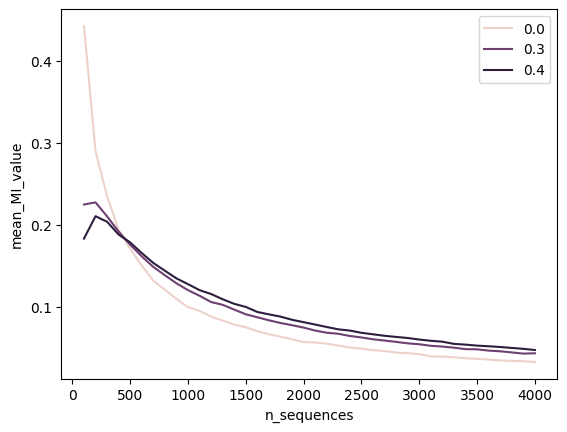

In [ ]:
fig, axes = plt.subplots(1,1)
sns.lineplot(data = nat_df, x="n_sequences", y = "mean_MI_value", hue ="pseudocount", units = "sim_ind", estimator = None, ax=axes)

plt.legend()


### Log plots for MI decay

In [8]:
MI_decay_values_folder_logitsprop = "other-analyses/MI_decay_MSAs/20-mutation-interval/100-sequences/100-rounds/msa-seed-simulations/MSA-1b/init-seq-sampled/logits-proposal/context-size-10/PF00004/MI-decay-MI-values/pseudo-0.4"
MI_decay_values_folder_randomprop = "other-analyses/MI_decay_MSAs/20-mutation-interval/100-sequences/100-rounds/msa-seed-simulations/MSA-1b/init-seq-sampled/random-proposal/context-size-10/PF00004/MI-decay-MI-values/pseudo-0.4"

folder_paths = [MI_decay_values_folder_logitsprop, MI_decay_values_folder_randomprop]

all_sim_decays = pd.DataFrame()

for MI_decay_values_folder in folder_paths:
    for file in os.listdir(MI_decay_values_folder):


        sim_df = pd.read_csv(os.path.join(MI_decay_values_folder, file), delimiter = "\t")

        all_sim_decays = pd.concat([all_sim_decays, sim_df]).reset_index(drop=True)

    
all_sim_decays = all_sim_decays.groupby(by = ["proposal_type","pseudocount","n_mutations"]).mean().reset_index()

# all_sim_decays["MI_log_transform"] = all_sim_decays["mean MI value"].apply(lambda x: np.log(x - 0.2425))

# fig, axes = plt.subplots(ncols=1, nrows=1)

# sns.scatterplot(data = all_sim_decays, x="n_mutations", y = "MI_log_transform", hue ="proposal_type",ax=axes)
# plt.legend()

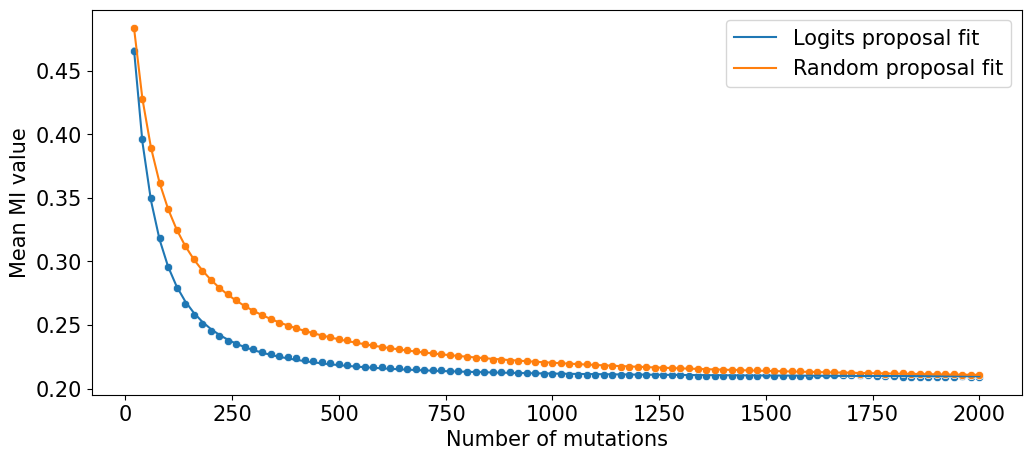

In [9]:
from scipy.optimize import curve_fit

def decay_fn_1(x, a, b, p, C):

    y = a/(x + b)**p + C
    return y

def decay_fn_2(x, a, b, p, C):

    y = a/(x + b) + C
    return y

def decay_fn_3(x,a,b,c,d):
    
    y = a*np.exp(-b*x) + c*np.exp(-d*x)
    return y

def decay_fn_4(x,a,b,c,d):
    
    y = a*np.exp(-b*x) + c
    return y


all_sim_decays_logitsprop = all_sim_decays.loc[all_sim_decays["proposal_type"] == "logits", :].reset_index(drop = True)
all_sim_decays_randomprop = all_sim_decays.loc[all_sim_decays["proposal_type"] == "random", :].reset_index(drop = True)

x_values_to_fit_logits = all_sim_decays_logitsprop["n_mutations"]
y_values_to_fit_logits = all_sim_decays_logitsprop["mean MI value"]

params_logits, cov_logits = curve_fit(decay_fn_1, x_values_to_fit_logits, y_values_to_fit_logits, method = "dogbox")

fit_y_logits = decay_fn_1(x_values_to_fit_logits, params_logits[0], params_logits[1], params_logits[2], params_logits[3])

fig, axes = plt.subplots(1,1, figsize = (12,5))

sns.scatterplot(x=all_sim_decays_logitsprop["n_mutations"], y=all_sim_decays_logitsprop["mean MI value"], ax = axes)
sns.lineplot(x=x_values_to_fit_logits, y=fit_y_logits, label='Logits proposal fit')

x_values_to_fit_random = all_sim_decays_randomprop["n_mutations"]
y_values_to_fit_random = all_sim_decays_randomprop["mean MI value"]

params_random, cov_random = curve_fit(decay_fn_1, x_values_to_fit_random, y_values_to_fit_random, method = "dogbox")

fit_y_random = decay_fn_1(x_values_to_fit_random, params_random[0], params_random[1], params_random[2], params_random[3])
sns.scatterplot(x=all_sim_decays_randomprop["n_mutations"], y=all_sim_decays_randomprop["mean MI value"])
sns.lineplot(x=x_values_to_fit_random, y=fit_y_random, label='Random proposal fit')
plt.legend()

plt.ylabel("Mean MI value", fontsize = 15)
plt.xlabel("Number of mutations", fontsize = 15)
plt.tick_params(labelbottom=True, axis='both', labelsize=15)
plt.legend(loc = "best", fontsize = 15)
# plt.title("Decay of MI with mutations(logits vs random proposal)", size = 18)


plt.savefig(f"inverse_poly_fit_pseudo_0.4.jpeg")

In [ ]:
params_logits

array([ 9.47402672, 12.06360859,  0.63980623,  0.30655333])

In [ ]:
params_random

array([34.17127792, 45.33092192,  0.84993326,  0.4223411 ])

In [ ]:
# inverse polynomial: logits -[5.42792761e+02, 6.89112853e+01, 1.65460055e+00, 2.42734270e-01] random - [38.15299311, 64.45899818,  1.05771877,  0.23723308]


In [ ]:
MI_MSAs_folder_logitsprop = "data/MI_decay_MSAs/20-mutation-interval/100-sequences/100-rounds/msa-seed-simulations/MSA-1b/init-seq-sampled/logits-proposal/context-size-10/PF00004/"
MI_MSAs_folder_randomprop = "data/MI_decay_MSAs/20-mutation-interval/100-sequences/100-rounds/msa-seed-simulations/MSA-1b/init-seq-sampled/random-proposal/context-size-10/PF00004/"

folder_paths = [MI_MSAs_folder_logitsprop, MI_MSAs_folder_randomprop]
timepoints = np.linspace(0,2000,11, dtype=int)
all_sim_decays = pd.DataFrame()

cur_dir = os.getcwd()
root_folder = os.path.join(cur_dir,"BIO-369 Assignment")

if not os.path.exists(root_folder):
    os.mkdir(root_folder)

for i,MI_MSAs_folder in enumerate(folder_paths):

    if i == 0:
        cur_MSA_folder = os.path.join(root_folder,"logits-proposal")
    else:
        cur_MSA_folder = os.path.join(root_folder,"random-proposal")
    
    if not os.path.exists(cur_MSA_folder):
        os.mkdir(cur_MSA_folder)

    
    for j, file in enumerate(os.listdir(MI_MSAs_folder)):

        if os.path.isdir(os.path.join(MI_MSAs_folder, file)):

            continue

        sim_df = pd.read_csv(os.path.join(MI_MSAs_folder, file), delimiter = "\t")

        for ind,k in enumerate(timepoints):

            sim_df_timept = sim_df.loc[sim_df["n_mutations"] == k, :]
            seq_tuples = [(name,seq) for name, seq in zip(sim_df_timept["sequence_name"], sim_df_timept["sequence"])]

            sim_folder = os.path.join(cur_MSA_folder, f"simulation-{j+1}")

            if not os.path.exists(sim_folder):
                os.mkdir(sim_folder)

            fasta_path = os.path.join(sim_folder, f"timepoint-{ind}.fasta")
            Seq_tuples_to_fasta(seq_tuples, fasta_path)

seed_MSA = "./data/protein-families-msa-seed/PF00004_seed.fasta"
seed_MSA = [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse(seed_MSA, "fasta")]

nat_folder = os.path.join(root_folder, "natural") 

if not os.path.exists(nat_folder):
    os.mkdir(nat_folder)     

for i in range(10):

    random_ind_1 = list(np.random.choice(range(1,len(seed_MSA)),100, replace = False))
    rand_MSA_1 = [seed_MSA[i] for i in random_ind_1]

    remaining_inds = list(set(range(len(seed_MSA))).difference(set(random_ind_1)))

    random_ind_2 = list(np.random.choice(remaining_inds,100, replace = False))
    rand_MSA_2 = [seed_MSA[i] for i in random_ind_2] 

    sim_folder = os.path.join(nat_folder, f"sample-pair-{i+1}")

    if not os.path.exists(sim_folder):
        os.mkdir(sim_folder)

    fasta_path_1 = os.path.join(sim_folder, "sample-1.fasta")
    fasta_path_2 = os.path.join(sim_folder, "sample-2.fasta")

    Seq_tuples_to_fasta(rand_MSA_1, fasta_path_1)
    Seq_tuples_to_fasta(rand_MSA_2, fasta_path_2)


    
    


### R-effective Scores

In [33]:
phylogeny = True
include_nat = True

protein_families = ["PF00004","PF00005","PF00041","PF00072","PF00096","PF00153"]
models_list = ["MSA-1b"]
init_seqs = ["0"]
proposal_types = ["logits"]
context_types = ["static"]
context_sizes = ["10"]
context_sampling_methods = ["random"]
r_effs = ["0.1","0.2","0.3","0.4","0.5","0.6","0.7","0.8","0.9","1.0"]

scores_folders_common_path = "./other-analyses/r-effective-analysis/scores/"

scores_folders = []
msas_folders = []
tree_scores_folders = []

max_nat_hmmer_score = {}
mean_stat_energy_score = {}
std_stat_energy_score = {}

tool_types = []
model_order = []
proposal_order = []
context_type_order = []
context_sampling_order = []
context_size_order = []
init_seq_order = []
r_eff_order = []


for family in protein_families:
                    
    scores_path_fam = scores_folders_common_path + f"{family}/"

    if not os.path.exists(scores_path_fam):
      continue

    for init_seq in init_seqs:

        scores_path_init = scores_path_fam + f"init-seq-{init_seq}/"

        if not os.path.exists(scores_path_init):
            continue

        for r_eff in r_effs:

            scores_path_r_eff = scores_path_init + f"scaling-{r_eff}/"

            if not os.path.exists(scores_path_r_eff):
                continue
      
            for context in context_types:
                
                scores_path_context = scores_path_r_eff + f"{context}-context/"

                if not os.path.exists(scores_path_context):
                    continue

                for context_size in context_sizes:
                    
                    scores_path_size = scores_path_context + f"{context_size}/"

                    if not os.path.exists(scores_path_size):
                        continue

                    if init_seq == "-1":
                        init_seq_dummy = "random"
                    else:
                        init_seq_dummy = init_seq

                    if context == "dynamic":
                    
                        for context_sampling_method in context_sampling_methods:
                            
                            scores_path_sampling = scores_path_size + f"{context_sampling_method}/"

                            if not os.path.exists(scores_path_sampling):
                                continue

                            scores_folders.append(scores_path_sampling)

                            tool_type = f"{context}-{context_sampling_method}-{context_size}"
                            tool_types.append(tool_type)
                            context_type_order.append(None)
                            context_sampling_order.append(None)
                            context_size_order.append(None)
                            init_seq_order.append(init_seq)
                            r_eff_order.append(r_eff)


                    elif context == "static":
                        
                        scores_folders.append(scores_path_size)
                        
                        tool_type = f"{context}-{context_size}-r-eff-{r_eff}"
                        tool_types.append(tool_type)
                        init_seq_order.append(init_seq)
                        r_eff_order.append(r_eff)

if include_nat:

  for family in protein_families:
    nat_scores_path = f"./scores/protein-families-msa-seed/{family}/" 
    scores_folders.append(nat_scores_path)

    scores = pd.read_csv(os.path.join(nat_scores_path, f"{family}_seed.tsv"), delimiter = "\t")
    max_nat_hmmer_score[family] = scores["hmmer_seq_score"].max()
    try:
      mean_stat_energy_score[family] = scores["stat_energy_scores"].mean()
      std_stat_energy_score[family] = scores["stat_energy_scores"].std()
    except:
      pass

    nat_msas_path = f"./data/protein-families-msa-seed/{family}/"
    msas_folders.append(nat_msas_path)
   
    tool_type = f"nat"
    tool_types.append(tool_type)
    init_seq_order.append(init_seq)
    r_eff_order.append(r_eff)

# tree_path = f"./data/seed-trees/{family}_seed.newick"
# tree = Phylo.read(tree_path,"newick")
# tree.root_at_midpoint()

In [34]:
from sklearn.metrics import r2_score

hd_dataframe = pd.DataFrame(columns=["tool","sim_ind","ham_dist_sim","ham_dist_corr_nat"])
sim_ind = 4

statistics_table = []

for j,folder in enumerate(scores_folders):
        
    for i,file in enumerate(os.listdir(folder)):

        if tool_types[j].startswith("nat"):
            continue

        family = re.findall("PF[0-9]{5}",folder)[0]
        r_eff = float(re.findall("scaling-([0-9.]+)",folder)[0])

        if not tool_types[j].startswith("nat"):
            file_sim_ind = file.split('.')[0]
            file_sim_ind = int(file_sim_ind.split('-')[1])
        else:
            file_sim_ind = sim_ind

        if file_sim_ind != sim_ind:
            continue
            
        file_path = os.path.join(folder,file)
        dist_dataframe = pd.DataFrame()
        
        df = pd.read_csv(file_path, delimiter="\t") 
        
        num_sim_array = np.array([list(seq) for seq in df["sequence"]], dtype=np.bytes_).view(np.uint8)
        
        distance_matrix_sim = cdist(num_sim_array,num_sim_array, "hamming")
        pairwise_distances_sim = distance_matrix_sim[np.triu_indices_from(distance_matrix_sim, k=1)]

        num_nat_array = np.array([list(seq) for seq in df["corr_nat_seq"]], dtype=np.bytes_).view(np.uint8)
        
        distance_matrix_nat = cdist(num_nat_array,num_nat_array, "hamming")
        pairwise_distances_nat = distance_matrix_nat[np.triu_indices_from(distance_matrix_nat, k=1)]

        dist_dataframe["ham_dist_sim"] = list(pairwise_distances_sim)
        dist_dataframe["ham_dist_corr_nat"] = list(pairwise_distances_nat)
        dist_dataframe["tool"] = tool_types[j]
        dist_dataframe["sim_ind"] = file_sim_ind
        dist_dataframe["family"] = family

        pearson_corr = pearsonr(dist_dataframe["ham_dist_sim"], dist_dataframe["ham_dist_corr_nat"])
        r2 = r2_score(dist_dataframe["ham_dist_sim"], dist_dataframe["ham_dist_corr_nat"])

        lin_fit = stats.linregress(dist_dataframe["ham_dist_sim"], dist_dataframe["ham_dist_corr_nat"])
        statistics_table.append({"family":family,"r_eff":r_eff,"corr":pearson_corr.statistic, "slope":lin_fit.slope, "intercept":lin_fit.intercept, "R2 score":r2})
        

        hd_dataframe = pd.concat((hd_dataframe, dist_dataframe)).reset_index(drop=True)

statistics_table = pd.DataFrame(statistics_table)

## Analyzing the slope, intercept and pearson correlation of hamming distance fit

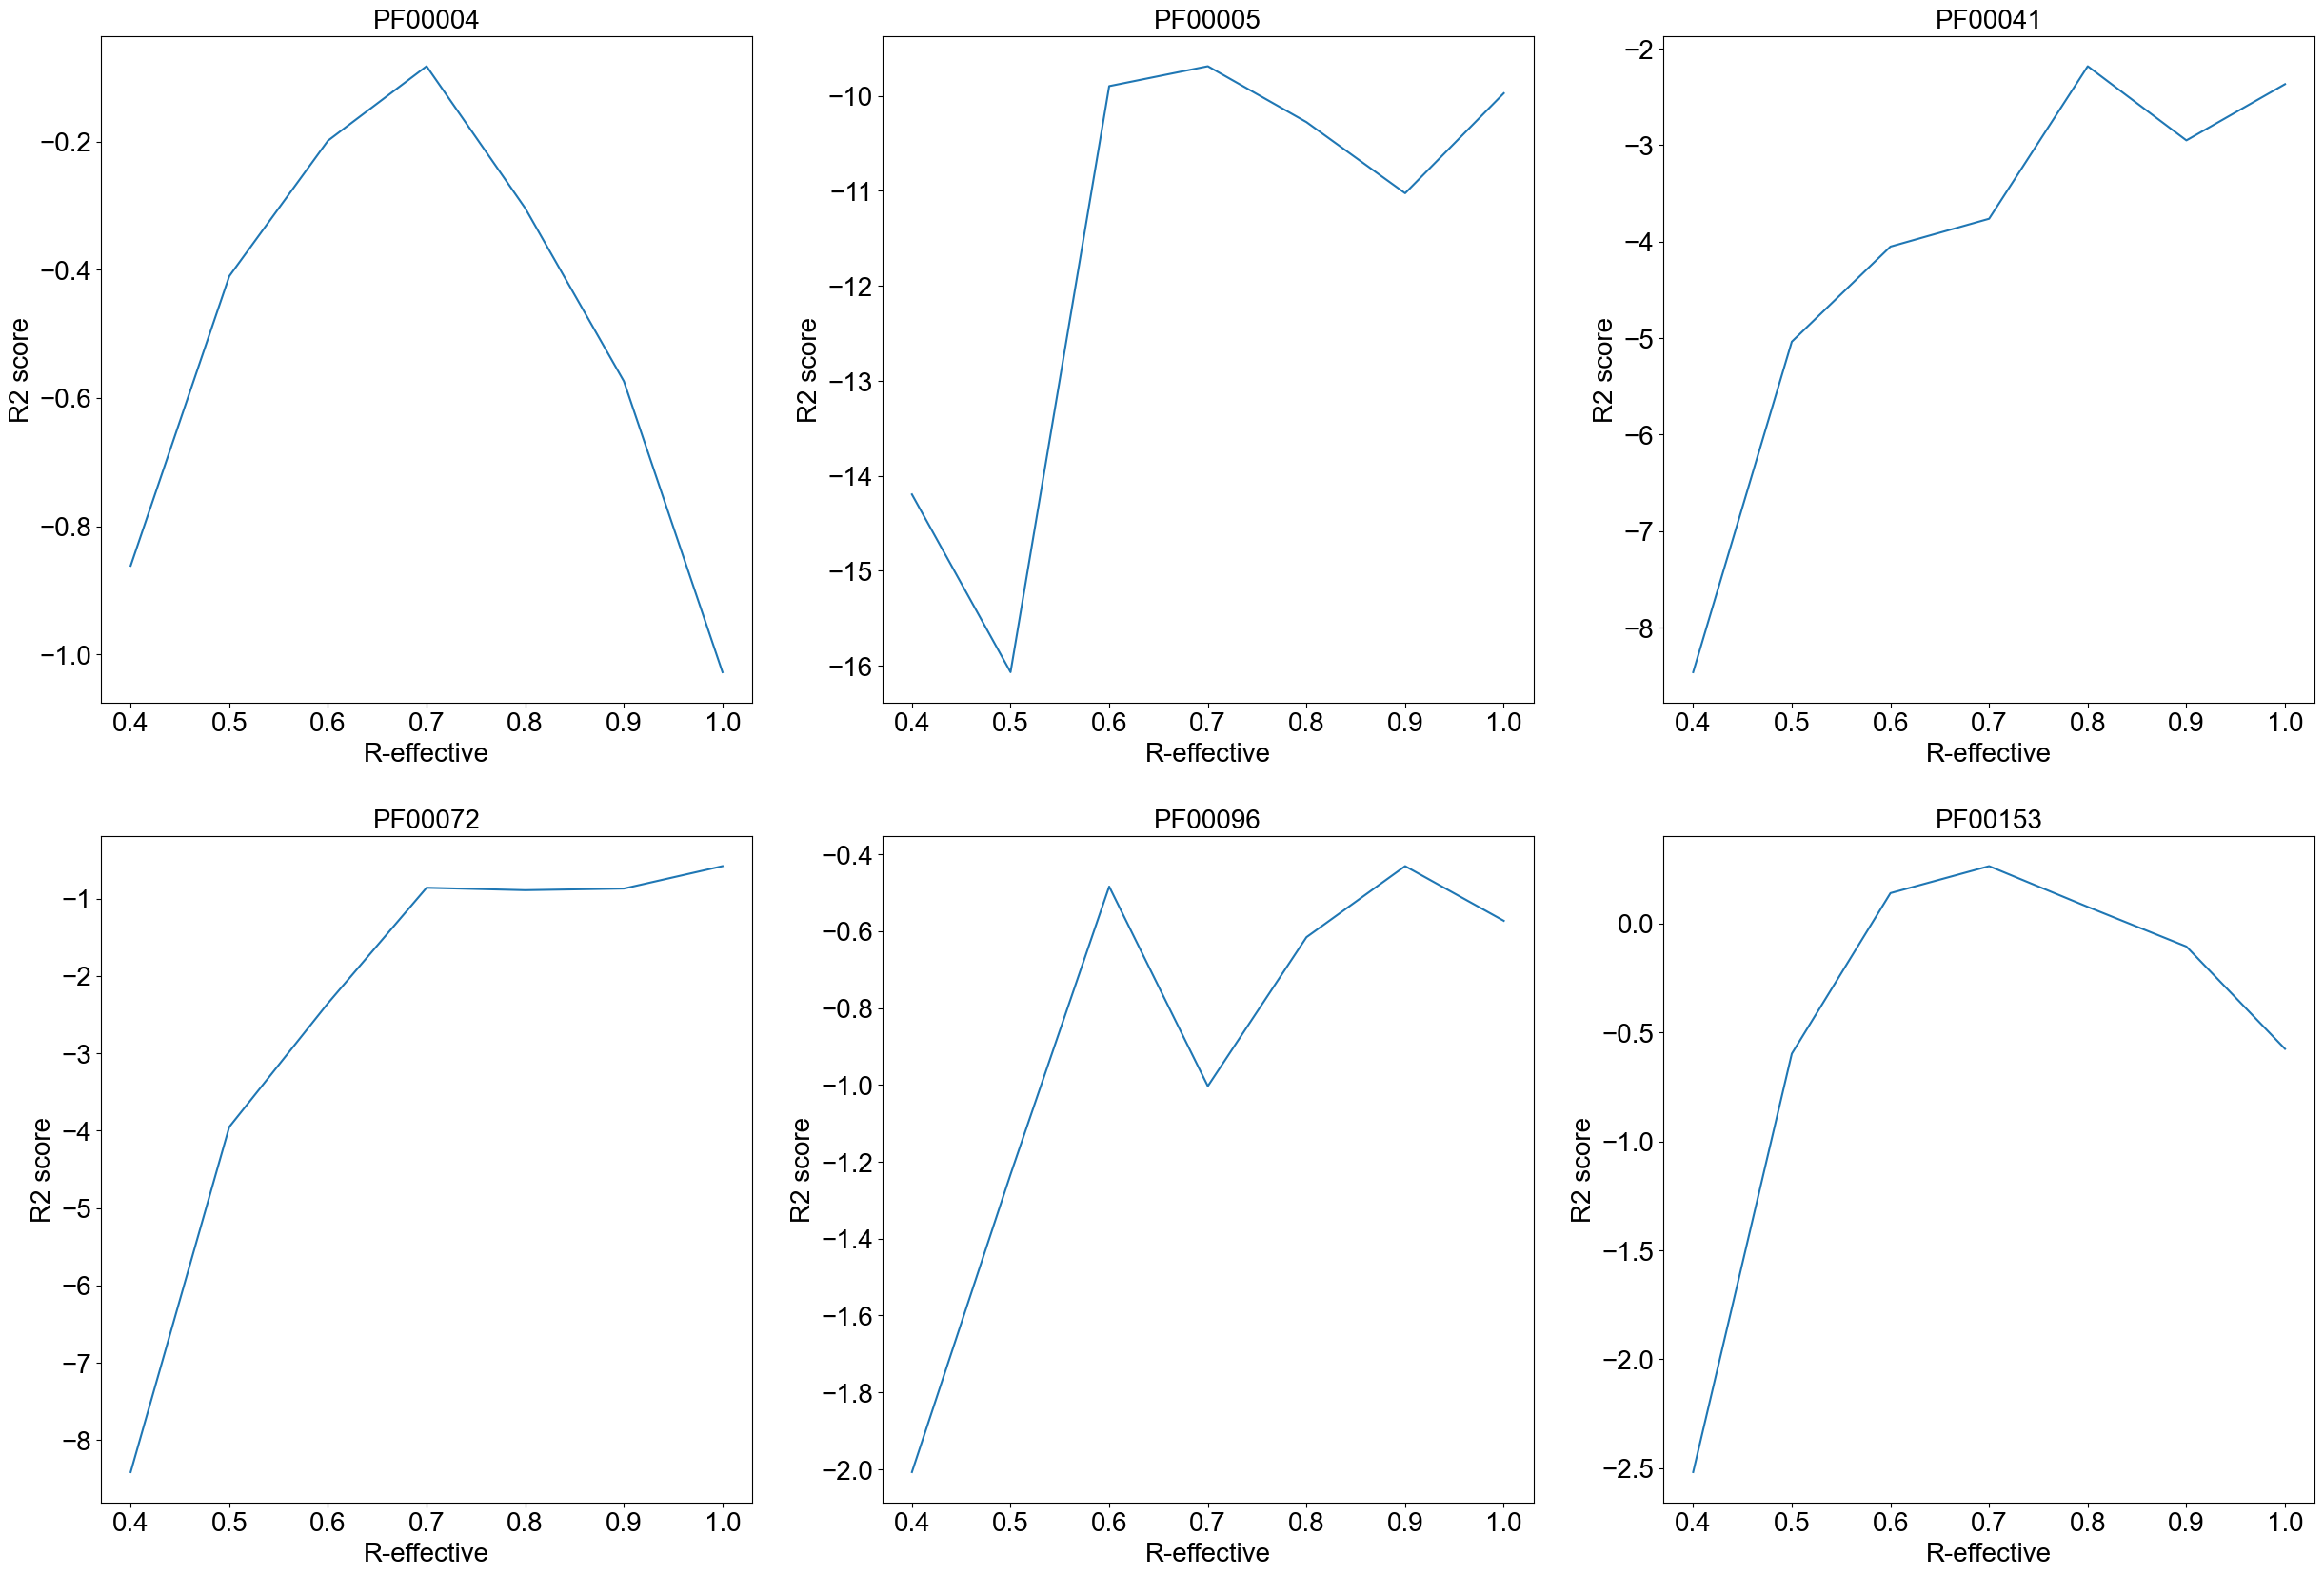

In [23]:
rcParams["font.family"] = "Arial"

fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (30,20))

for k, fam in enumerate(protein_families):

    statistics_table_fam = statistics_table.loc[statistics_table["family"] == fam, :].reset_index(drop = True)

    i = floor(k/3)
    j = k % 3

    # sns.lineplot(x = "r_eff", y="slope", data = statistics_table_fam,  ax = axes[i][j], label="slope")
    # sns.lineplot(x = "r_eff", y="intercept", data = statistics_table_fam,  ax = axes[i][j], label="intercept")
    # sns.lineplot(x = "r_eff", y="corr", data = statistics_table_fam,  ax = axes[i][j], label="corr")
    sns.lineplot(x = "r_eff", y="R2 score", data = statistics_table_fam,  ax = axes[i][j])
    axes[i][j].set_ylabel("R2 score",  fontsize = 20)
    axes[i][j].set_xlabel("R-effective",  fontsize = 20)
    axes[i][j].set_title(f"{fam}",  fontsize = 20)

    axes[i][j].tick_params(labelbottom=True, axis='both', labelsize=20)

plt.savefig("R2_vs_Reff.jpeg")

In [5]:
from Bio.Align import substitution_matrices

blomat = substitution_matrices.load("BLOSUM45")

In [6]:
blosum_dist_mat = np.array([ 
      [0, 1.31097856157468, 1.06573001937323, 1.2682782988532, 0.90471293383305, 1.05855446876905, 1.05232790675508, 0.769574440593014, 1.27579668305679, 0.964604099952603, 0.987178199640556, 1.05007594438157, 1.05464162250736, 1.1985987403937, 0.967404475245526, 0.700490199584332, 0.880060189098976, 1.09748548316685, 1.28141710375267, 0.800038509951648],
      [1.31097856157468, 0, 0.8010890222701, 0.953340718498495, 1.36011107208122, 0.631543775840481, 0.791014908659279, 1.15694899265629, 0.761152570032029, 1.45014917711188, 1.17792001455227, 0.394661075648738, 0.998807558909651, 1.135143404599, 1.15432562628921, 1.05309036790541, 1.05010474413616, 1.03938321130789, 0.963216908696184, 1.20274751778601],
      [1.06573001937323, 0.8010890222701, 0, 0.488217214273568, 1.10567116937273, 0.814970207038261, 0.810176440932339, 0.746487413974582, 0.61876156253224, 1.17886558630004, 1.52003670190022, 0.808442678243754, 1.2889025816028, 1.16264109995678, 1.18228799147301, 0.679475681649858, 0.853658619686283, 1.68988558988005, 1.24297493464833, 1.55207513886163],
      [1.2682782988532, 0.953340718498495, 0.488217214273568, 0, 1.31581050011876, 0.769778474953791, 0.482077627352988, 0.888361752320536, 0.736360849050364, 1.76756333403346, 1.43574761894039, 0.763612910719347, 1.53386612356483, 1.74323672079854, 0.886347403928663, 0.808614044804528, 1.01590147813779, 1.59617804551619, 1.1740494822217, 1.46600946033173],
      [0.90471293383305, 1.36011107208122, 1.10567116937273, 1.31581050011876, 0, 1.3836789310481, 1.37553994252576, 1.26740695314856, 1.32361065635259, 1.26087264215993, 1.02417540515351, 1.37259631233791, 1.09416720447891, 0.986982088723923, 1.59321190226694, 0.915638787768407, 0.913042853922533, 1.80744143643002, 1.3294417177004, 0.830022143283238],
      [1.05855446876905, 0.631543775840481, 0.814970207038261, 0.769778474953791, 1.3836789310481, 0, 0.506942797642807, 1.17699648087288, 0.614595446514896, 1.17092829494457, 1.19833088638994, 0.637341078675405, 0.806490842729072, 1.83315144709714, 0.932064479113502, 0.850321696813199, 1.06830084665916, 1.05739353225849, 0.979907428113788, 1.5416250309563],
      [1.05232790675508, 0.791014908659279, 0.810176440932339, 0.482077627352988, 1.37553994252576, 0.506942797642807, 0, 1.17007322676118, 0.769786956320484, 1.46659942462342, 1.19128214039009, 0.633592151371708, 1.27269395724349, 1.44641491621774, 0.735428579892476, 0.845319988414402, 1.06201695511881, 1.324395996498, 1.22734387448031, 1.53255698189437],
      [0.769574440593014, 1.15694899265629, 0.746487413974582, 0.888361752320536, 1.26740695314856, 1.17699648087288, 1.17007322676118, 0, 1.1259007054424, 1.7025415585924, 1.38293205218175, 1.16756929156758, 1.17264582493965, 1.33271035269688, 1.07564768421292, 0.778868281341681, 1.23287107008366, 0.968539655354582, 1.42479529031801, 1.41208067821187],
      [1.27579668305679, 0.761152570032029, 0.61876156253224, 0.736360849050364, 1.32361065635259, 0.614595446514896, 0.769786956320484, 1.1259007054424, 0, 1.4112324673522, 1.14630894167097, 0.967795284542623, 0.771479459384692, 1.10468029976148, 1.12334774065132, 1.02482926701639, 1.28754326478771, 1.27439749294131, 0.468683841672724, 1.47469999960758],
      [0.964604099952603, 1.45014917711188, 1.17886558630004, 1.76756333403346, 1.26087264215993, 1.17092829494457, 1.46659942462342, 1.7025415585924, 1.4112324673522, 0, 0.433350517223017, 1.463460928818, 0.462965544381851, 0.66291968000662, 1.07010201755441, 1.23000200130049, 0.973485453109068, 0.963546200571036, 0.708724769805536, 0.351200119909572],
      [0.987178199640556, 1.17792001455227, 1.52003670190022, 1.43574761894039, 1.02417540515351, 1.19833088638994, 1.19128214039009, 1.38293205218175, 1.14630894167097, 0.433350517223017, 0, 1.49770950074319, 0.473800072611076, 0.538473125003292, 1.37979627224964, 1.5859723170438, 0.996267398224516, 0.986095542821092, 0.725310666139274, 0.570542199221932],
      [1.05007594438157, 0.394661075648738, 0.808442678243754, 0.763612910719347, 1.37259631233791, 0.637341078675405, 0.633592151371708, 1.16756929156758, 0.967795284542623, 1.463460928818, 1.49770950074319, 0, 1.0079761868248, 1.44331961488922, 0.924599080166146, 1.06275728888356, 1.05974425835993, 1.04892430642749, 0.972058829603409, 1.21378822764856],
      [1.05464162250736, 0.998807558909651, 1.2889025816028, 1.53386612356483, 1.09416720447891, 0.806490842729072, 1.27269395724349, 1.17264582493965, 0.771479459384692, 0.462965544381851, 0.473800072611076, 1.0079761868248, 0, 0.72479754849538, 1.1699868662153, 1.34481214251794, 1.06435197383538, 1.05348497728858, 0.774878150710318, 0.609532859331199],
      [1.1985987403937, 1.135143404599, 1.16264109995678, 1.74323672079854, 0.986982088723923, 1.83315144709714, 1.44641491621774, 1.33271035269688, 1.10468029976148, 0.66291968000662, 0.538473125003292, 1.44331961488922, 0.72479754849538, 0, 1.32968844979665, 1.21307373491949, 0.960087571600877, 0.475142555482979, 0.349485367759138, 0.692733248746636],
      [0.967404475245526, 1.15432562628921, 1.18228799147301, 0.886347403928663, 1.59321190226694, 0.932064479113502, 0.735428579892476, 1.07564768421292, 1.12334774065132, 1.07010201755441, 1.37979627224964, 0.924599080166146, 1.1699868662153, 1.32968844979665, 0, 0.979087429691819, 0.97631161216338, 1.21751652292503, 1.42156458605332, 1.40887880416009],
      [0.700490199584332, 1.05309036790541, 0.679475681649858, 0.808614044804528, 0.915638787768407, 0.850321696813199, 0.845319988414402, 0.778868281341681, 1.02482926701639, 1.23000200130049, 1.5859723170438, 1.06275728888356, 1.34481214251794, 1.21307373491949, 0.979087429691819, 0, 0.56109848274013, 1.76318885009194, 1.29689226231656, 1.02015839286433],
      [0.880060189098976, 1.05010474413616, 0.853658619686283, 1.01590147813779, 0.913042853922533, 1.06830084665916, 1.06201695511881, 1.23287107008366, 1.28754326478771, 0.973485453109068, 0.996267398224516, 1.05974425835993, 1.06435197383538, 0.960087571600877, 0.97631161216338, 0.56109848274013, 0, 1.39547634461879, 1.02642577026706, 0.807404666228614],
      [1.09748548316685, 1.03938321130789, 1.68988558988005, 1.59617804551619, 1.80744143643002, 1.05739353225849, 1.324395996498, 0.968539655354582, 1.27439749294131, 0.963546200571036, 0.986095542821092, 1.04892430642749, 1.05348497728858, 0.475142555482979, 1.21751652292503, 1.76318885009194, 1.39547634461879, 0, 0.320002937404137, 1.268589159299],
      [1.28141710375267, 0.963216908696184, 1.24297493464833, 1.1740494822217, 1.3294417177004, 0.979907428113788, 1.22734387448031, 1.42479529031801, 0.468683841672724, 0.708724769805536, 0.725310666139274, 0.972058829603409, 0.774878150710318, 0.349485367759138, 1.42156458605332, 1.29689226231656, 1.02642577026706, 0.320002937404137, 0, 0.933095433689795],
      [0.800038509951648, 1.20274751778601, 1.55207513886163, 1.46600946033173, 0.830022143283238, 1.5416250309563, 1.53255698189437, 1.41208067821187, 1.47469999960758, 0.351200119909572, 0.570542199221932, 1.21378822764856, 0.609532859331199, 0.692733248746636, 1.40887880416009, 1.02015839286433, 0.807404666228614, 1.268589159299, 0.933095433689795, 0]])

mapping_dict = {k:v for k, v in zip(list("ARNDCQEGHILKMFPSTWYV-"),range(21))}



In [23]:
from numba import njit

@njit
def calc_fasttree_distance(seq1, seq2, blosum_dist_mat):

    assert len(seq1) == len(seq2), "seqs must be of the same length"

    dist = 0
    count = 0

    for i in range(len(seq1)):

        char_1 = seq1[i]
        char_2 = seq2[i]

        if char_1 == 20 or char_2 == 20:
            continue

        dist += blosum_dist_mat[char_1, char_2]
        count += 1

    if count == 0:
        return 3.0
    
    uncorrected_dist = dist/count

    corrected_dist = min(3.0, -1.3 * np.log(1 - uncorrected_dist)) if uncorrected_dist < 1 else 3.0

    return corrected_dist

    

In [24]:
fd_dataframe = pd.DataFrame(columns=["tool","sim_ind","fd_sim","fd_corr_nat"])
sim_ind = 4

statistics_table = []

for j,folder in enumerate(scores_folders):

    if tool_types[j].startswith("nat"):
            continue
        
    for i,file in enumerate(os.listdir(folder)):

        family = re.findall("PF[0-9]{5}",folder)[0]
        r_eff = float(re.findall("scaling-([0-9.]+)",folder)[0])

        if not tool_types[j].startswith("nat"):
            file_sim_ind = file.split('.')[0]
            file_sim_ind = int(file_sim_ind.split('-')[1])
        else:
            file_sim_ind = sim_ind

        if file_sim_ind != sim_ind:
            continue
            
        file_path = os.path.join(folder,file)
        dist_dataframe = pd.DataFrame()
        
        df = pd.read_csv(file_path, delimiter="\t") 

        fd_distances_sim = []
        fd_distances_corr_nat = []

        for k in range(len(df)):

            for l in range(k+1, len(df)):

                seq_1_sim = df.loc[k,"sequence"]
                seq_2_sim = df.loc[l, "sequence"]

                seq_1_sim = np.array([mapping_dict[char] for char in seq_1_sim])
                seq_2_sim = np.array([mapping_dict[char] for char in seq_2_sim])

                dist_sim = calc_fasttree_distance(seq_1_sim, seq_2_sim, blosum_dist_mat)
                fd_distances_sim.append(dist_sim)

                seq_1_nat = df.loc[k,"corr_nat_seq"]
                seq_2_nat = df.loc[l, "corr_nat_seq"]

                seq_1_nat = np.array([mapping_dict[char] for char in seq_1_nat])
                seq_2_nat = np.array([mapping_dict[char] for char in seq_2_nat])

                dist_nat = calc_fasttree_distance(seq_1_nat, seq_2_nat, blosum_dist_mat)
                fd_distances_corr_nat.append(dist_nat)

        dist_dataframe["fd_sim"] = list(fd_distances_sim)
        dist_dataframe["fd_corr_nat"] = list(fd_distances_corr_nat)
        dist_dataframe["tool"] = tool_types[j]
        dist_dataframe["sim_ind"] = file_sim_ind
        dist_dataframe["family"] = re.findall("PF[0-9]{5}",folder)[0]

        pearson_corr = pearsonr(dist_dataframe["fd_sim"], dist_dataframe["fd_corr_nat"])

        lin_fit = stats.linregress(dist_dataframe["fd_sim"], dist_dataframe["fd_corr_nat"])
        statistics_table.append({"family":family,"r_eff":r_eff,"corr":pearson_corr.statistic, "slope":lin_fit.slope, "intercept":lin_fit.intercept})
        
        fd_dataframe = pd.concat((fd_dataframe, dist_dataframe)).reset_index(drop=True)

fd_dataframe = fd_dataframe.dropna()
statistics_table = pd.DataFrame(statistics_table)

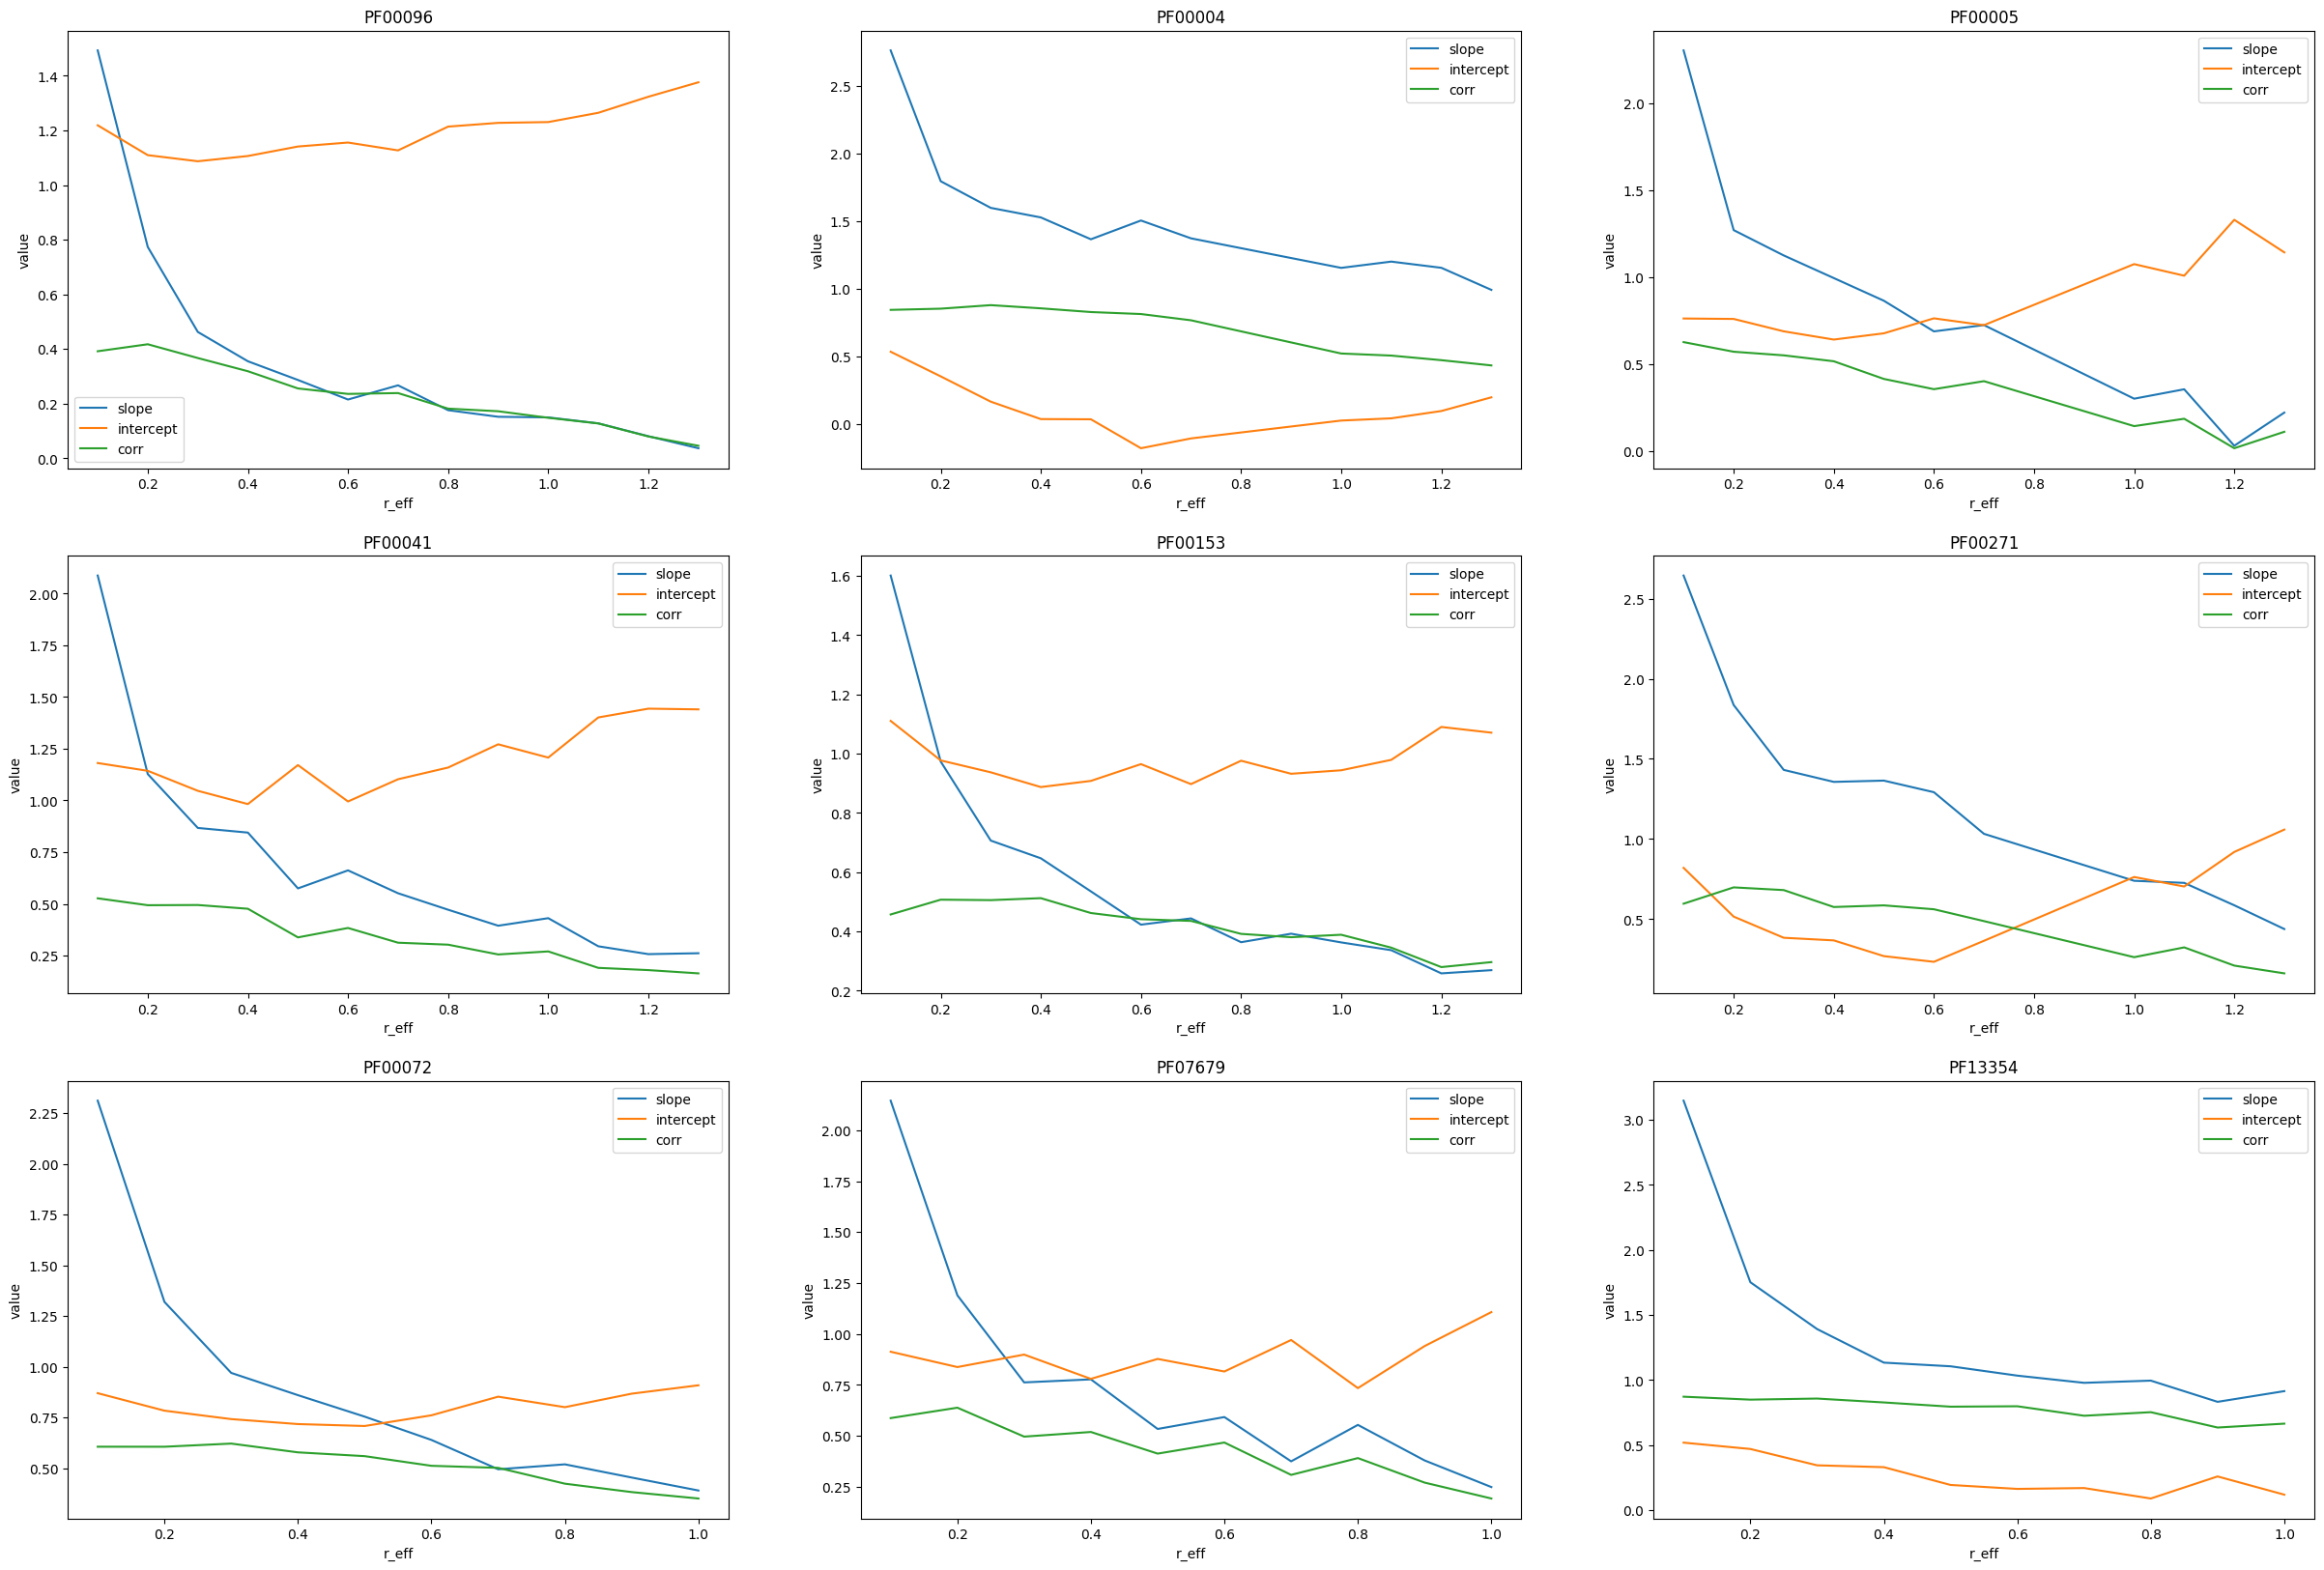

In [ ]:
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (30,20))

for k, fam in enumerate(protein_families):

    statistics_table_fam = statistics_table.loc[statistics_table["family"] == fam, :].reset_index(drop = True)

    i = floor(k/3)
    j = k % 3

    sns.lineplot(x = "r_eff", y="slope", data = statistics_table_fam,  ax = axes[i][j], label="slope")
    sns.lineplot(x = "r_eff", y="intercept", data = statistics_table_fam,  ax = axes[i][j], label="intercept")
    sns.lineplot(x = "r_eff", y="corr", data = statistics_table_fam,  ax = axes[i][j], label="corr")
    axes[i][j].set_ylabel("value")
    axes[i][j].set_title(f"{fam}")

plt.savefig("slope_intercept_corr_families.jpeg")

## Initial Processing

#### No Averaging

In [ ]:
all_metrics_dataframe = pd.DataFrame()

for j,folder in enumerate(scores_folders):
    
    main_dataframe = pd.DataFrame()
    family = re.findall("PF[0-9]{5}",folder)[0]
    
    for i,file in enumerate(os.listdir(folder)):

        if not tool_types[j].startswith("nat") and tool_types[j] != "full_sampling":
            file_sim_ind = file.split('.')[0]
            file_sim_ind = int(file_sim_ind.split('-')[1])
        else:
            file_sim_ind = 1

        file_path = os.path.join(folder,file)
        df = pd.read_csv(file_path, delimiter="\t")
        
        df["Tool"] = tool_types[j]
        df["Sim index"] = file_sim_ind
        df["Family"] = family
        df["Model"] = model_order[j]
        df["Proposal"] = proposal_order[j]
        df["Context type"] = context_type_order[j]
        df["Context sampling"] = context_sampling_order[j]
        df["Context size"] = context_size_order[j]
        df["Init seq"] = init_seq_order[j]
        
        main_dataframe = pd.concat((main_dataframe, df)).reset_index(drop=True)

    main_dataframe = pd.DataFrame(main_dataframe)
    main_dataframe["hmmer_seq_score_normalized"] = main_dataframe["hmmer_seq_score"]/max_nat_hmmer_score[family]
    try:
        main_dataframe["stat_energy_score_z_scored"] = (main_dataframe["stat_energy_scores"] - mean_stat_energy_score[family])/std_stat_energy_score[family]
    except:
        pass
    
    all_metrics_dataframe = pd.concat([all_metrics_dataframe, main_dataframe]).reset_index(drop = True)

### No Averaging - Tree Scores

In [ ]:
tree_metrics_dataframe = pd.DataFrame()

for j,folder in enumerate(tree_scores_folders):
    
    main_dataframe = pd.DataFrame()
    family = re.findall("PF[0-9]{5}",folder)[0]
    
    for i,file in enumerate(os.listdir(folder)):

        row = {"tool":tool_types[j]}
        file_path = os.path.join(folder,file)
        df = pd.read_csv(file_path, delimiter="\t")
        
        df["Tool"] = tool_types[j]
        df["Sim index"] = file_sim_ind
        df["Family"] = family
        df["Model"] = model_order[j].split('-')[0]
        df["Proposal"] = proposal_order[j]
        df["Context type"] = context_type_order[j]
        df["Context sampling"] = context_sampling_order[j]
        df["Context size"] = context_size_order[j]
        df["Init seq"] = init_seq_order[j]
        
        main_dataframe = pd.concat((main_dataframe, df)).reset_index(drop=True)

    main_dataframe = pd.DataFrame(main_dataframe)
    tree_metrics_dataframe = pd.concat([tree_metrics_dataframe, main_dataframe]).reset_index(drop = True)



#### Averaging

In [35]:
all_metrics_dataframe = pd.DataFrame()

max_nat_hmmer_scores = {}

for j,folder in enumerate(scores_folders):
    
    main_dataframe = []
    family = re.findall("PF[0-9]{5}",folder)[0]
    
    for i,file in enumerate(os.listdir(folder)):


        if not tool_types[j].startswith("nat"):
            file_sim_ind = file.split('.')[0]
            file_sim_ind = int(file_sim_ind.split('-')[1])
        else:
            file_sim_ind = 1
            file_path = os.path.join(folder,file)
            main_dataframe = pd.read_csv(file_path, delimiter="\t").iloc[:,4:]
            names = [elem + "_mean" for elem in list(main_dataframe.columns)]
            main_dataframe.columns = names
            main_dataframe["Tool"] = tool_types[j]
            main_dataframe["Sim index"] = file_sim_ind
            main_dataframe["Family"] = re.findall("PF[0-9]{5}",folder)[0]
            main_dataframe["Tool"] = tool_types[j]
            main_dataframe["R-effective"] = r_eff_order[j]
            # main_dataframe["hmmer_seq_score_mean"] = main_dataframe["hmmer_seq_score_mean"]/max_nat_hmmer_score[family]
            # all_metrics_dataframe = pd.concat([all_metrics_dataframe, main_dataframe]).reset_index(drop = True)

            continue

        row = {"tool":tool_types[j],"sim_ind":file_sim_ind, "family": family}
        
        file_path = os.path.join(folder,file)
        df = pd.read_csv(file_path, delimiter="\t")
        
        if phylogeny or tool_types[j].startswith("nat"):
            df = df.iloc[:,4:].mean(axis = 0)
        else:
            df = df.iloc[:,2:].mean(axis = 0)

        names = [elem + "_mean" for elem in list(df.index)]
        df.index = names

        record = df.to_dict()
        row.update(record)

        main_dataframe.append(row)

    main_dataframe = pd.DataFrame(main_dataframe)
    main_dataframe["hmmer_seq_score_mean_normalized"] = main_dataframe["hmmer_seq_score_mean"]/max_nat_hmmer_score[family]
    try:
        main_dataframe["stat_energy_scores_mean_z_scored"] = (main_dataframe["stat_energy_scores_mean"] - mean_stat_energy_score[family])/std_stat_energy_score[family]
    except:
        pass

    main_dataframe["Tool"] = tool_types[j]
    main_dataframe["Sim index"] = file_sim_ind
    main_dataframe["Family"] = family
    main_dataframe["R-effective"] = r_eff_order[j]
    all_metrics_dataframe = pd.concat([all_metrics_dataframe, main_dataframe]).reset_index(drop = True)


In [36]:
x_value = "R-effective"
hue = None

palette = [(235, 172, 35),(184, 0, 88), (0, 140, 249), (0, 110, 0), (0, 187, 173), (209, 99, 230), (178, 69, 2),
            (255, 146, 135), (89, 84, 214), (0, 198, 248), (135, 133, 0), (0, 167, 108), (189, 189,189)]

palette = [(a/255,b/255,c/255) for a,b,c in palette]


### PLDDT Scores

/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (13) than needed (10), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (13) than needed (

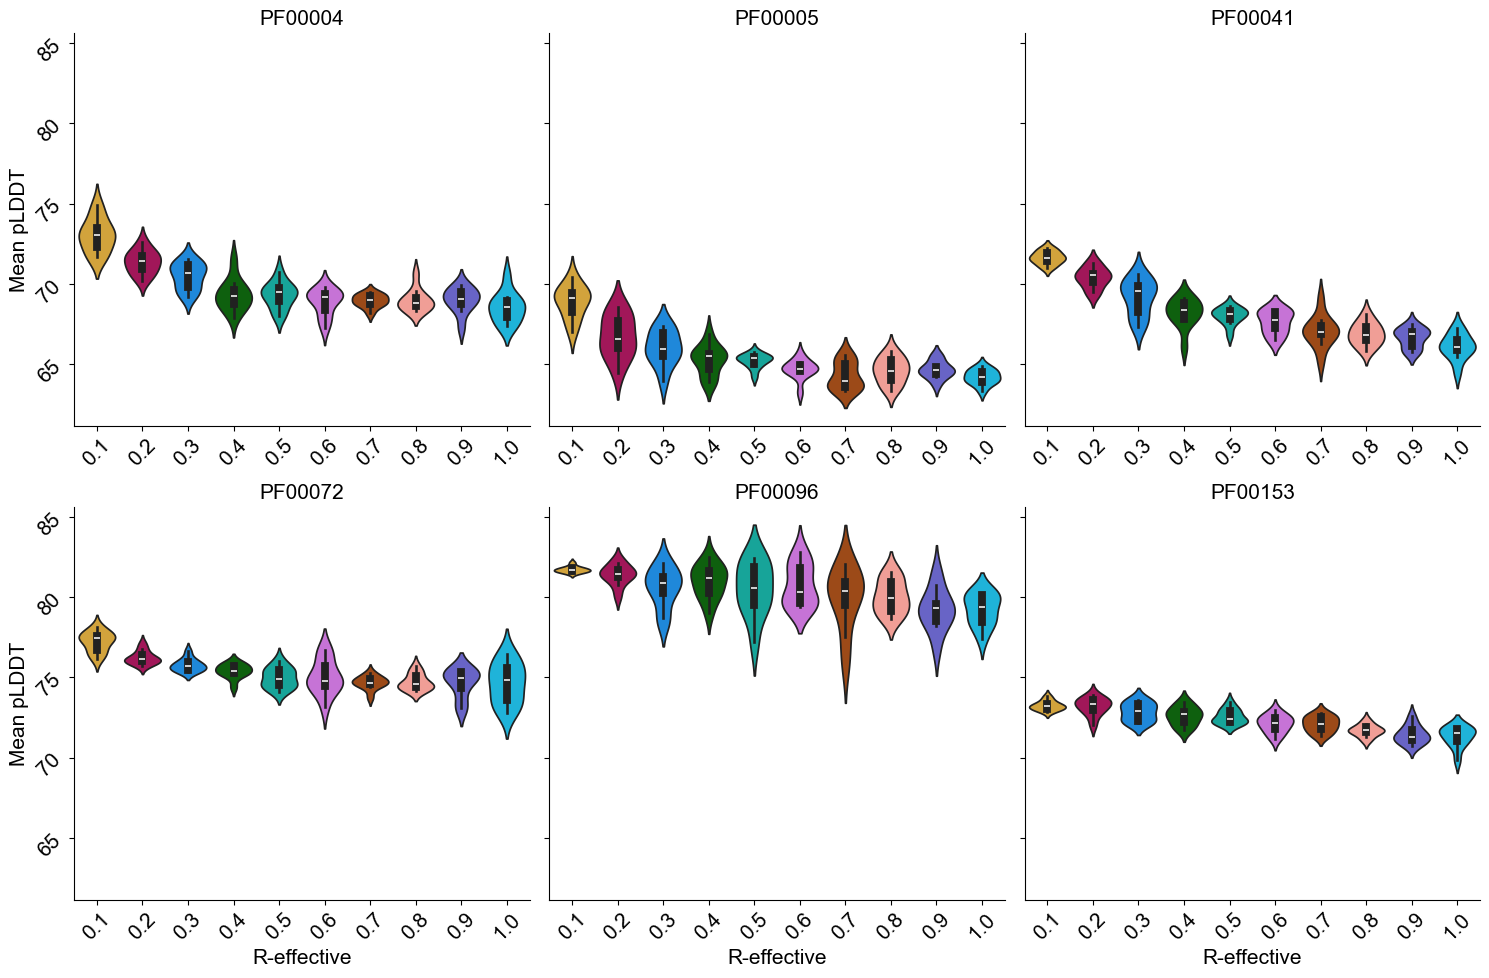

In [37]:
rcParams['figure.figsize'] = 30,10

metric = [name for name in list(all_metrics_dataframe.columns) if name.startswith("plddt")][0]

if "mean" in metric:
    metric_name = "Mean pLDDT"
else:
    metric_name = "pLDDT"

g = sns.FacetGrid(all_metrics_dataframe, col="family", col_wrap=3, margin_titles=True, height=5, aspect= 1)
g.map_dataframe(sns.violinplot, x=x_value, y=metric, hue = hue, inner = "box", palette = palette)
# g.figure.suptitle(f"Comparison of Performance across Models ({metric})", size = 20)
# fig = sns.violinplot(data = all_metrics_dataframe, y=metric, x = "family", hue="tool", inner = None)

for i,ax in enumerate(g.axes.flat):
    ax.set_ylabel(metric_name, fontsize = 15)
    ax.set_xlabel(x_value, fontsize = 15)
    ax.tick_params(labelbottom=True, axis='both', labelsize=15, labelrotation = 45)
    if i%3 == 1 and hue is not None:
        ax.legend(loc = "best", title = hue, fontsize = 15, title_fontsize=15)
    ax.set_title(ax.get_title().split(' ')[2], size = 15, )
    
plt.tight_layout()
g.figure.subplots_adjust(top=0.95)

plt.savefig(f'{x_value}_vs_{metric}.png', bbox_inches='tight')

plt.show()

### HMMer Scores

/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (13) than needed (10), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (13) than needed (

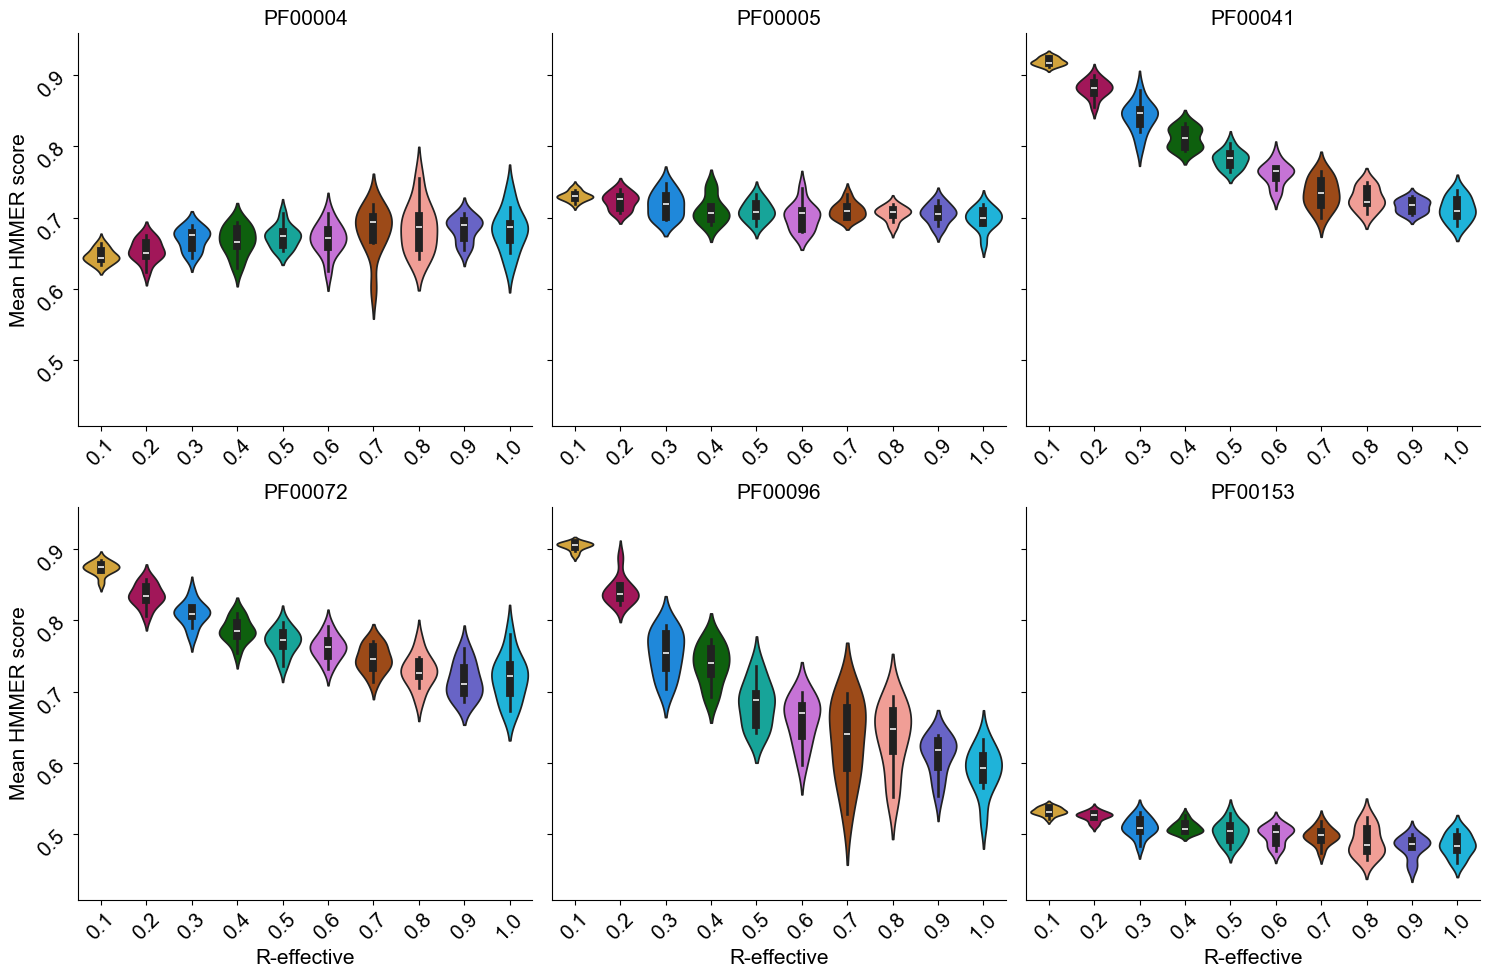

In [38]:
rcParams['figure.figsize'] = 30,10

metric = [name for name in list(all_metrics_dataframe.columns) if name.startswith("hmmer")][1]

if "mean" in metric:
    metric_name = "Mean HMMER score"
else:
    metric_name = "HMMER score"

g = sns.FacetGrid(all_metrics_dataframe, col="family", col_wrap=3, margin_titles=True, height=5, aspect= 1)
g.map_dataframe(sns.violinplot, x=x_value, y=metric, hue = hue, inner = "box", palette = palette)
# g.figure.suptitle(f"Comparison of Performance across Models ({metric})", size = 20)
# fig = sns.violinplot(data = all_metrics_dataframe, y=metric, x = "family", hue="tool", inner = None)

for i,ax in enumerate(g.axes.flat):
    ax.set_ylabel(metric_name, fontsize = 15)
    ax.set_xlabel(x_value, fontsize = 15)
    ax.tick_params(labelbottom=True, axis='both', labelsize=15, labelrotation = 45)
    if i%3 == 1 and hue is not None:
        ax.legend(loc = "best", title = hue, fontsize = 15, title_fontsize=15)
    ax.set_title(ax.get_title().split(' ')[2], size = 15, )
    
plt.tight_layout()
g.figure.subplots_adjust(top=0.95)

plt.savefig(f'{x_value}_vs_{metric}.png', bbox_inches='tight')

plt.show()



## Statistical Energy Scores

/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (13) than needed (10), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (13) than needed (

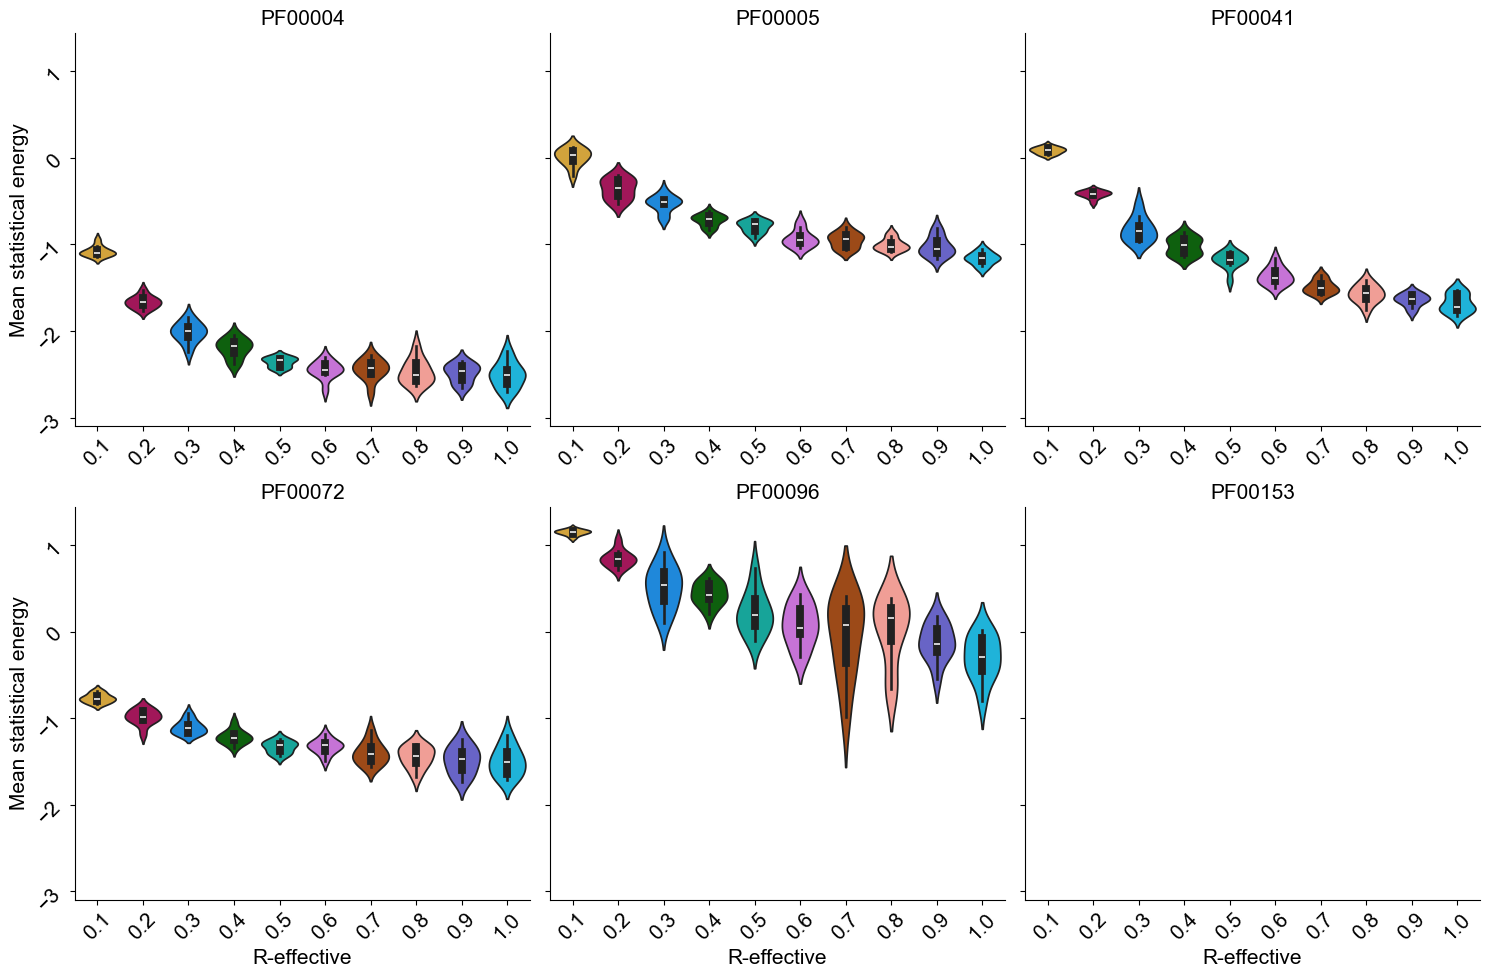

In [39]:
rcParams['figure.figsize'] = 30,10

# all_metrics_non_zero = all_metrics_dataframe.loc[all_metrics_dataframe["stat_energy_scores_ESM2_ref"] > 0, :].reset_index(drop = True)

metric = [name for name in list(all_metrics_dataframe.columns) if name.startswith("stat")][1]

if "mean" in metric:
    metric_name = "Mean statistical energy"
else:
    metric_name = "Statistical energy"

g = sns.FacetGrid(all_metrics_dataframe, col="family", col_wrap=3, margin_titles=True, height=5, aspect= 1)
g.map_dataframe(sns.violinplot, x=x_value, y=metric, hue = hue, inner = "box", palette = palette)
# g.figure.suptitle(f"Comparison of Performance across Models ({metric})", size = 20)
# fig = sns.violinplot(data = all_metrics_dataframe, y=metric, x = "family", hue="tool", inner = None)

for i,ax in enumerate(g.axes.flat):
    ax.set_ylabel(metric_name, fontsize = 15)
    ax.set_xlabel(x_value, fontsize = 15)
    ax.tick_params(labelbottom=True, axis='both', labelsize=15, labelrotation = 45)
    if i%3 == 1 and hue is not None:
        ax.legend(loc = "best", title = hue, fontsize = 15, title_fontsize=15)
    ax.set_title(ax.get_title().split(' ')[2], size = 15, )
    
plt.tight_layout()
g.figure.subplots_adjust(top=0.95)

plt.savefig(f'{x_value}_vs_{metric}.png', bbox_inches='tight')

plt.show()

## Average Minimum Distance to a Natural Sequence

/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (13) than needed (10), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (13) than needed (

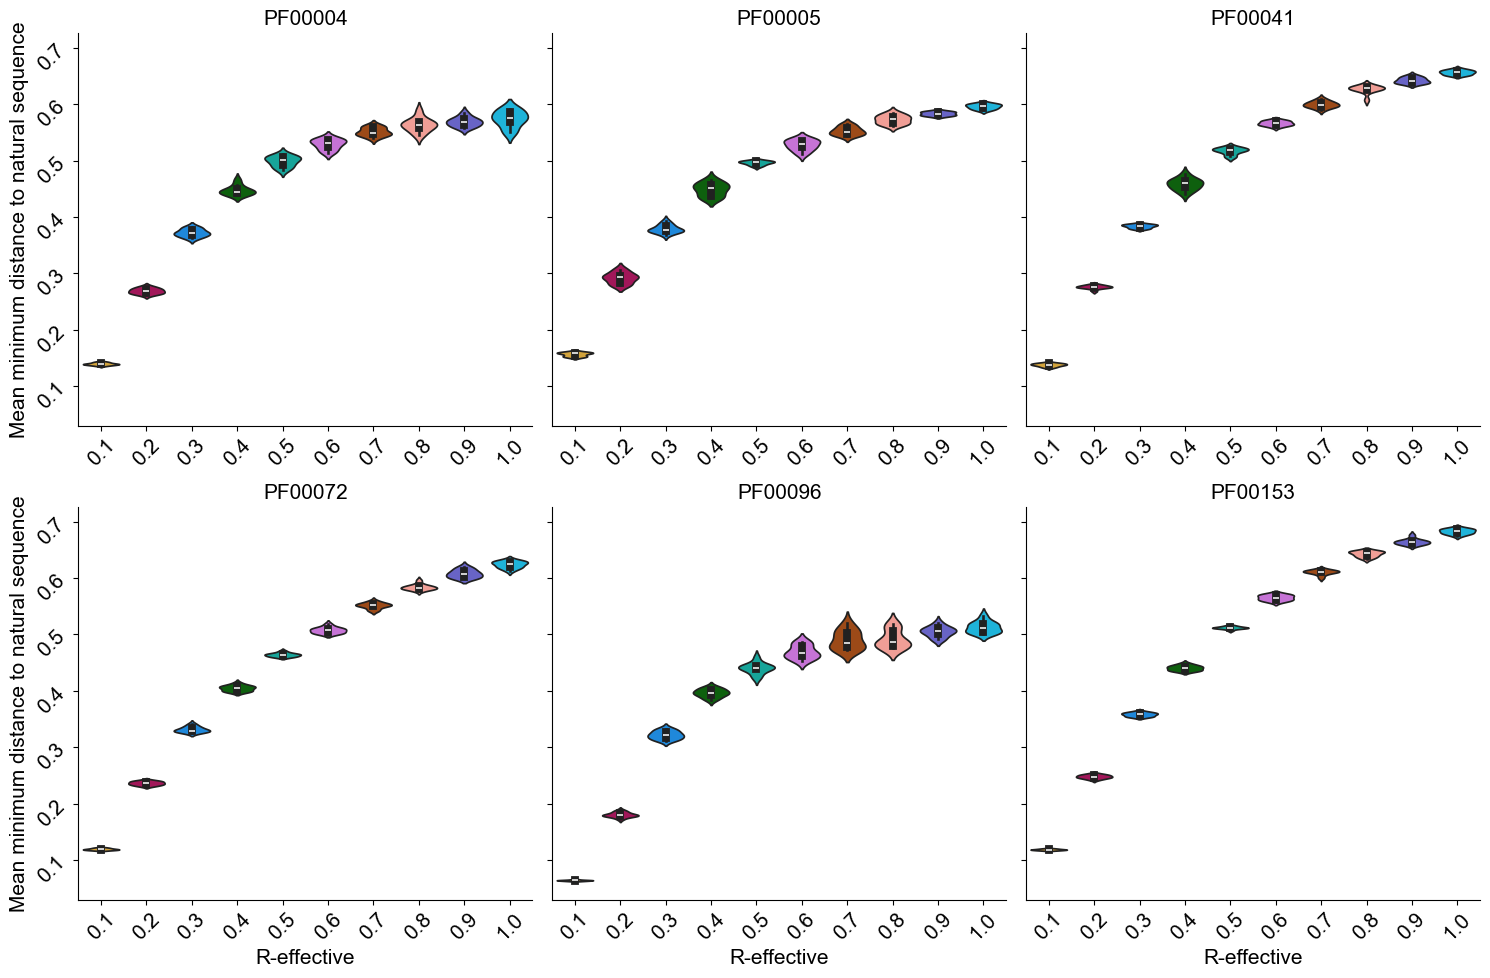

In [40]:
rcParams['figure.figsize'] = 30,10

metric = [name for name in list(all_metrics_dataframe.columns) if name.startswith("min_natural")][0]

nat_tool = None
try:
    nat_tool = [tool for tool in list(all_metrics_dataframe["tool"].unique()) if tool.startswith("nat")][0]
except:
    pass

all_metrics_dataframe_no_nat = all_metrics_dataframe.loc[all_metrics_dataframe["tool"] != nat_tool, :].reset_index(drop = True)

if "mean" in metric:
    metric_name = "Mean minimum distance to natural sequence"
else:
    metric_name = "Minimum distance to natural sequence"

g = sns.FacetGrid(all_metrics_dataframe, col="family", col_wrap=3, margin_titles=True, height=5, aspect= 1)
g.map_dataframe(sns.violinplot, x=x_value, y=metric, hue = hue, inner = "box", palette = palette)
# g.figure.suptitle(f"Comparison of Performance across Models ({metric})", size = 20)
# fig = sns.violinplot(data = all_metrics_dataframe, y=metric, x = "family", hue="tool", inner = None)

for i,ax in enumerate(g.axes.flat):
    ax.set_ylabel(metric_name, fontsize = 15)
    ax.set_xlabel(x_value, fontsize = 15)
    ax.tick_params(labelbottom=True, axis='both', labelsize=15, labelrotation = 45)
    if i%3 == 1 and hue is not None:
        ax.legend(loc = "best", title = hue, fontsize = 15, title_fontsize=15)
    ax.set_title(ax.get_title().split(' ')[2], size = 15, )
    
plt.tight_layout()
g.figure.subplots_adjust(top=0.95)

plt.savefig(f'{x_value}_vs_{metric}.png', bbox_inches='tight')

plt.show()

## Average Maximum Distance within an MSA

/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (13) than needed (10), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (13) than needed (

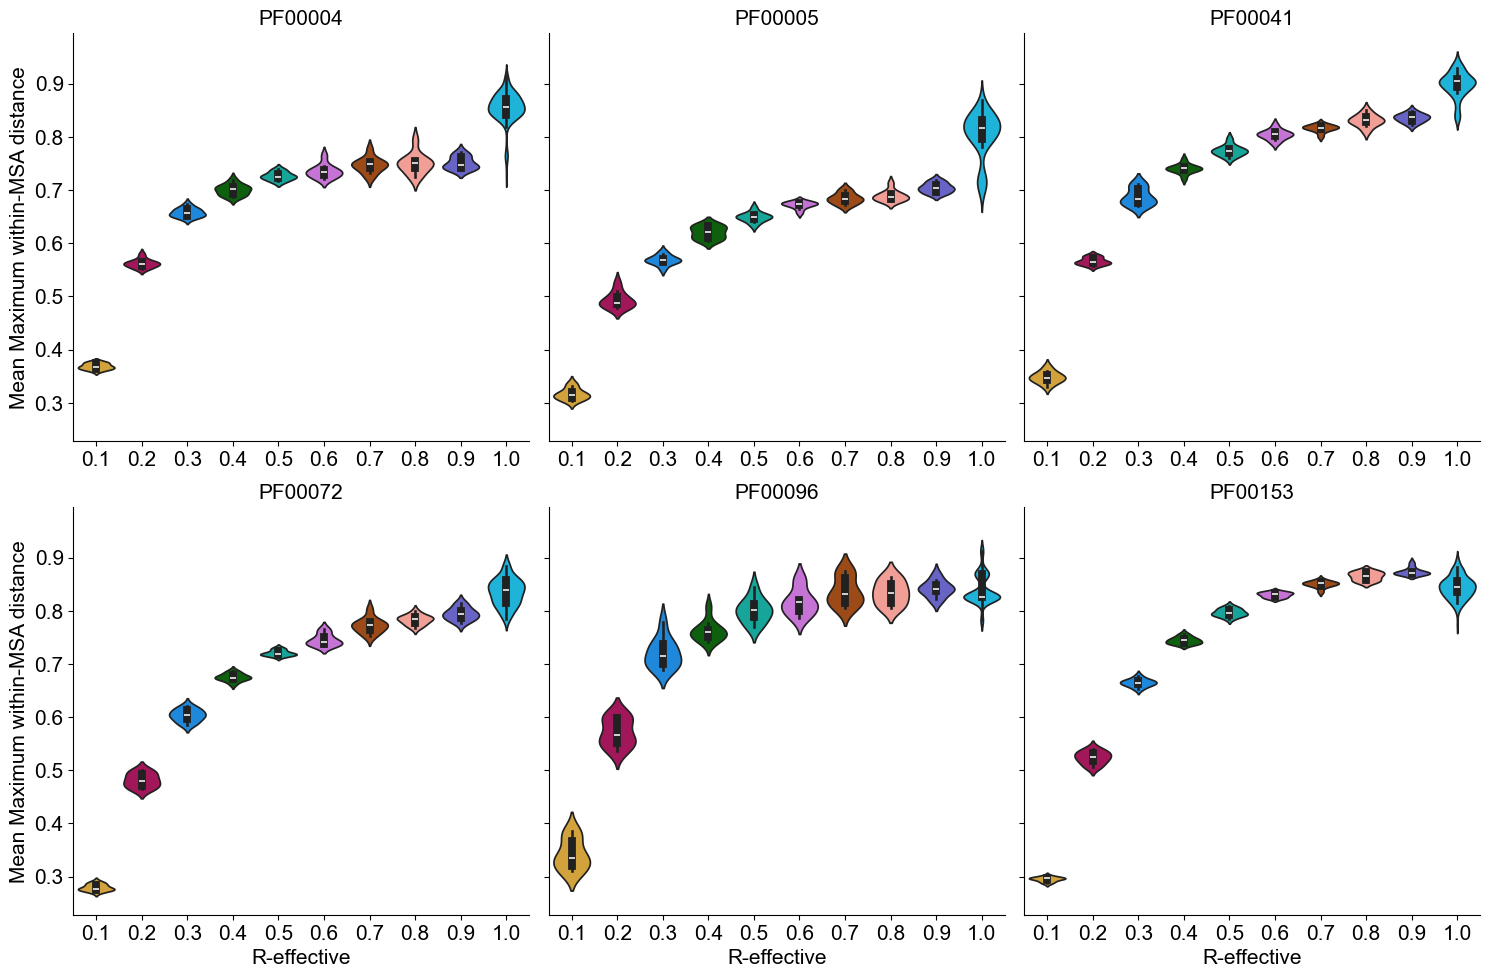

In [42]:
rcParams['figure.figsize'] = 30, 10

metric = [name for name in list(all_metrics_dataframe.columns) if name.startswith("max_self")][0]

if "mean" in metric:
    metric_name = "Mean Maximum within-MSA distance"
else:
    metric_name = "Maximum within-MSA distance"

g = sns.FacetGrid(all_metrics_dataframe, col="Family", col_wrap=3, margin_titles=True, height=5, aspect= 1)
g.map_dataframe(sns.violinplot, x=x_value, y=metric, hue = hue, inner = "box", palette = palette)

for i,ax in enumerate(g.axes.flat):
    ax.set_ylabel(metric_name, fontsize = 15)
    ax.set_xlabel(x_value, fontsize = 15)
    ax.tick_params(labelbottom=True, axis='both', labelsize=15)
    if i%3 == 1 and hue is not None:
        ax.legend(loc = "best", title = hue, fontsize = 15, title_fontsize=15)
    ax.set_title(ax.get_title().split(' ')[2], size = 15, )

plt.tight_layout()
g.figure.subplots_adjust(top=0.95)

plt.savefig(f'{x_value}_vs_{metric}.png', bbox_inches='tight')

plt.show()

### Tree Metrics - Normalized RF

In [52]:
tree_metrics_dataframe

""


In [50]:
rcParams['figure.figsize'] = 11.7,6

metric = [name for name in list(tree_metrics_dataframe.columns) if name.startswith("norm")][0]

fig = sns.violinplot(data = tree_metrics_dataframe,x = "family", y=metric, hue="tool", inner="box")
plt.xticks(rotation=90)

# plt.savefig(f'{metric}.png',bbox_inches="tight")

plt.show()

IndexError: list index out of range

### Tree Metrics - MAE

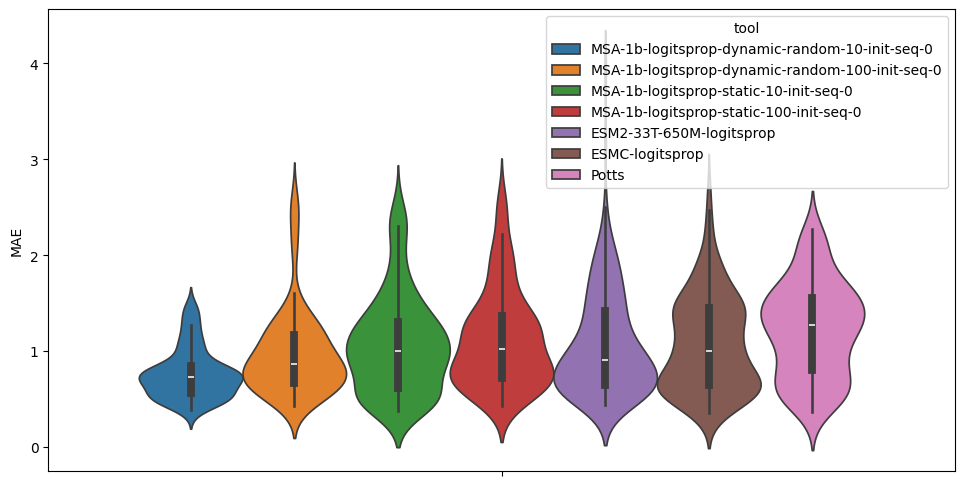

In [ ]:
rcParams['figure.figsize'] = 11.7,6

metric = [name for name in list(tree_metrics_dataframe.columns) if name.startswith("MAE")][0]

fig = sns.violinplot(data = tree_metrics_dataframe, y=metric, hue="tool", inner="box")
plt.xticks(rotation=90)

# plt.savefig(f'{metric}.png',bbox_inches="tight")

plt.show()

### Tree Metrics - KF Distance

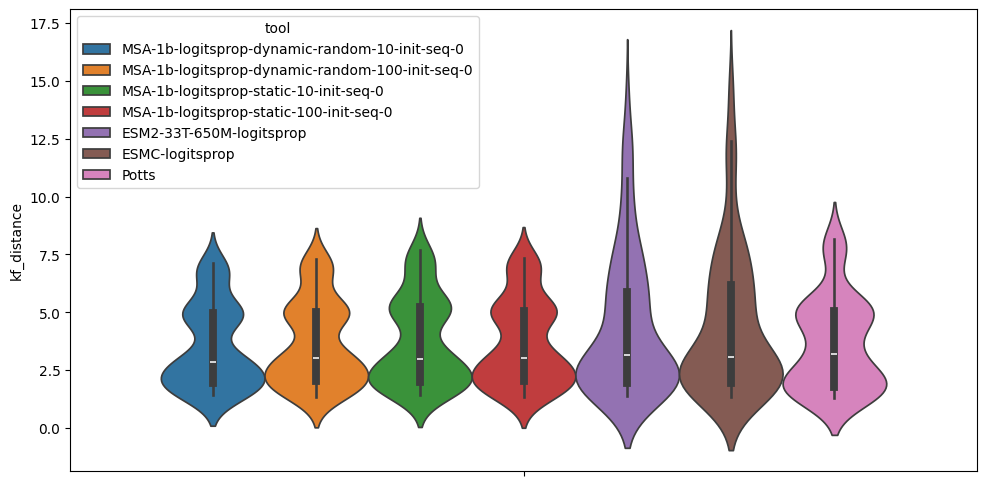

In [ ]:
rcParams['figure.figsize'] = 11.7,6

metric = [name for name in list(tree_metrics_dataframe.columns) if name.startswith("kf")][0]

fig = sns.violinplot(data = tree_metrics_dataframe, y=metric, hue="tool", inner="box")
plt.xticks(rotation=90)

plt.savefig(f'{metric}.png',bbox_inches="tight")

plt.show()